### **Premisa**: Gonzalo recibio una herencia importante y quiere invertir el dinero en algo que genere capital de manera sostenida para no tener que trabajar mas. Una de las recomendaciones que recibio, ya que vive en BsAs, es iniciar una carrera como 'empresario Airbnb'. Esto suena bien, pero la decision de si es un buen negocio y de que forma encararlo (# de propiedades para comprar, tipo, ubicacion) parece dificil. Con el objetivo de tomar una decision informada, trabajaremos con el dataset de Inside Airbnb de Buenos Aires para tratar de encontrar una formula que aumente las chances de convertirse en un empresario Airbnb **exitoso** _(aun no sabemos lo que significa en terminos del ds)_

In [82]:
import pandas as pd
from pandas.api.types import CategoricalDtype
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as st
from scipy.stats import describe
from scipy.stats import chi2_contingency, kendalltau, f_oneway, pointbiserialr
#import requests

In [83]:
def plot_pie(data, column, ax=None, startangle=90, palette='pastel', title=None):
    counts = data[column].value_counts()
    
    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 3))
    
    ax.pie(
        counts,
        labels=counts.index,
        autopct='%1.1f%%',
        startangle=startangle,
        colors=sns.color_palette(palette)
    )
    ax.set_title(title if title else f'Distribución de "{column}"')
    ax.legend(loc="best")
    ax.axis('equal') # Asegura que el gráfico sea circular

In [84]:
# Función para graficar
def plot_histograma(data, column, figsize=(6, 3), bins=15, kde=True, mvd=True, shade=True, snk=False):
    skewness = (data[column]).skew()
    kurtosis = (data[column]).kurt()
    media = (data[column]).mean()
    var = (data[column]).var()
    std = (data[column]).std()
    plt.figure(figsize=figsize)
    plt.grid(axis='y')
    sns.histplot(data[column], bins=bins, kde=kde)
    if snk:
        plt.figtext(0.7, 0.8, f'Asimetría: {skewness:.2f}', fontsize=10, color='blue')
        plt.figtext(0.715, 0.73, f'Curtosis: {kurtosis:.2f}', fontsize=10, color='blue')
        plt.axvline(media, color='red', linestyle='--', label='Media')

1. Cargamos el dataset de 'listings'. Hay uno resumido y otro extendido. El resumido parece mas util

In [47]:
df = pd.read_csv("listings_ext.csv")

2. Primera idea de que hay

In [48]:
pd. set_option('display.max_columns', None)
df.head()

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,host_url,host_profile_id,host_profile_url,host_name,host_since,hosts_time_as_user_years,hosts_time_as_user_months,hosts_time_as_host_years,hosts_time_as_host_months,host_location,host_about,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_thumbnail_url,host_picture_url,host_neighbourhood,host_listings_count,host_total_listings_count,host_verifications,host_has_profile_pic,host_identity_verified,neighbourhood,neighbourhood_cleansed,neighbourhood_group_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms,bathrooms_text,bedrooms,beds,amenities,price,minimum_nights,maximum_nights,minimum_minimum_nights,maximum_minimum_nights,minimum_maximum_nights,maximum_maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm,calendar_updated,has_availability,availability_30,availability_60,availability_90,availability_365,calendar_last_scraped,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,availability_eoy,number_of_reviews_ly,estimated_occupancy_l365d,estimated_revenue_l365d,first_review,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,42610838,https://www.airbnb.com/rooms/42610838,20260125052844,2026-01-25,city scrape,"Puerto Madero a 3 cuadras, centro, bello , tea...","Unbeatable location half a block away, 50 mete...",NaN,https://a0.muscache.com/pictures/miso/Hosting-...,224049389,https://www.airbnb.com/users/show/224049389,1469188629918707060,https://www.airbnb.com/users/profile/146918862...,Gabriela,NaN,7,2,5,11,NaN,NaN,NaN,NaN,NaN,t,NaN,https://a0.muscache.com/im/pictures/user/ba7f6...,NaN,3,NaN,NaN,t,t,NaN,San Nicolas,NaN,-34.599976,-58.374195,Entire rental unit,Entire home/apt,2,1.0,1 bath,1.0,1.0,"[""Kitchen"", ""Air conditioning"", ""Wifi"", ""TV""]",NaN,7.0,365.0,7.0,7.0,365.0,365.0,7.0,365.0,NaN,t,30,35,36,244,2026-01-25,0,0,0,220,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,2,0,0,NaN
1,1305876403852901802,https://www.airbnb.com/rooms/1305876403852901802,20260125052844,2026-01-25,city scrape,Apart estudio en Microcentro,"Located in the heart of Buenos Aires, this stu...",NaN,https://a0.muscache.com/pictures/miso/Hosting-...,25649070,https://www.airbnb.com/users/show/25649070,1465347917068117288,https://www.airbnb.com/users/profile/146534791...,Federico,NaN,11,0,3,7,"Autonomous City of Buenos Aires, Argentina",NaN,NaN,NaN,NaN,f,NaN,https://a0.muscache.com/im/users/25649070/prof...,NaN,1,NaN,NaN,t,t,NaN,San Nicolas,NaN,-34.600382,-58.372692,Entire rental unit,Entire home/apt,2,1.0,1 bath,1.0,1.0,"[""Paid parking on premises"", ""Air conditioning...",NaN,2.0,365.0,2.0,2.0,365.0,365.0,2.0,365.0,NaN,t,7,16,32,307,2026-01-25,1,0,0,283,1,0,NaN,2025-01-18,2025-01-18,3.00,4.00,2.00,3.00,3.00,5.00,4.00,NaN,NaN,1,1,0,0,0.08
2,1542233033640525302,https://www.airbnb.com/rooms/1542233033640525302,20260125052844,2026-01-25,city scrape,"Departamento en Buenos Aires, abasto shopping",From this central accommodation your group wil...,NaN,https://a0.muscache.com/pictures/hosting/Hosti...,153014015,https://www.airbnb.com/users/show/153014015,1468500000533080859,https://www.airbnb.com/users/profile/146850000...,Marco,NaN,8,3,7,10,"Olivos, Argentina",Responsable amable atento y amigable,NaN,NaN,NaN,f,NaN,https://a0.muscache.com/im/pictures/user/4e988...,NaN,1,NaN,NaN,t,t,NaN,Balvanera,NaN,-34.603295,-58.409527,Entire rental unit,Entire home/apt,2,1.0,1 bath,1.0,2.0,"[""Smoke alarm"", ""Wifi"", ""Kitchen"", ""Fire extin...",NaN,7.0,365.0,7.0,7.0,365.0,365.0,7.0,365.0,NaN,t,0,21,51,326,2026-01-25,0,0,0,302,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN

In [49]:
df.shape

(27348, 85)

In [50]:
num_cols = df.select_dtypes(include=['number']).shape[1]
str_cols = df.select_dtypes(include=['object', 'string']).shape[1]

print("Atributos numericos:", num_cols)
print("Atributos string:", str_cols)

Atributos numericos: 60
Atributos string: 25


27348 obs, 85 atributos, la mayoria numericos pero posiblemente muchos de ellos de poco interes. Por ello hay que hacer EDA

In [51]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 27348 entries, 0 to 27347
Data columns (total 85 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            27348 non-null  int64  
 1   listing_url                                   27348 non-null  str    
 2   scrape_id                                     27348 non-null  int64  
 3   last_scraped                                  27348 non-null  str    
 4   source                                        27348 non-null  str    
 5   name                                          27348 non-null  str    
 6   description                                   26752 non-null  str    
 7   neighborhood_overview                         0 non-null      float64
 8   picture_url                                   27347 non-null  str    
 9   host_id                                       27348 non-null  int64  
 1

3. Contamos cantidad de nulos

In [52]:
pd.options.display.min_rows = 115
print(df.isnull().sum(axis=0).sort_values(ascending=False))

calendar_updated                                27348
host_since                                      27348
neighbourhood_group_cleansed                    27348
neighbourhood                                   27348
host_verifications                              27348
host_total_listings_count                       27348
host_neighbourhood                              27348
host_thumbnail_url                              27348
host_acceptance_rate                            27348
host_response_rate                              27348
host_response_time                              27348
estimated_revenue_l365d                         27348
price                                           27348
neighborhood_overview                           27348
instant_bookable                                27348
license                                         26887
host_about                                      11784
host_location                                    5783
review_scores_accuracy      

Eliminamos los atributos vacios

In [53]:
df3_1 = df.drop(columns=['calendar_updated', 'host_since', 'neighbourhood_group_cleansed','neighbourhood','host_verifications','host_total_listings_count','host_neighbourhood','host_thumbnail_url','host_acceptance_rate','host_response_rate','host_response_time','estimated_revenue_l365d', 'price', 'neighborhood_overview', 'instant_bookable', 'license', 'host_about'])
df3_1.head()

,id,listing_url,scrape_id,last_scraped,source,name,description,picture_url,host_id,host_url,host_profile_id,host_profile_url,host_name,hosts_time_as_user_years,hosts_time_as_user_months,hosts_time_as_host_years,hosts_time_as_host_months,host_location,host_is_superhost,host_picture_url,host_listings_count,host_has_profile_pic,host_identity_verified,neighbourhood_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms,bathrooms_text,bedrooms,beds,amenities,minimum_nights,maximum_nights,minimum_minimum_nights,maximum_minimum_nights,minimum_maximum_nights,maximum_maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm,has_availability,availability_30,availability_60,availability_90,availability_365,calendar_last_scraped,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,availability_eoy,number_of_reviews_ly,estimated_occupancy_l365d,first_review,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,42610838,https://www.airbnb.com/rooms/42610838,20260125052844,2026-01-25,city scrape,"Puerto Madero a 3 cuadras, centro, bello , tea...","Unbeatable location half a block away, 50 mete...",https://a0.muscache.com/pictures/miso/Hosting-...,224049389,https://www.airbnb.com/users/show/224049389,1469188629918707060,https://www.airbnb.com/users/profile/146918862...,Gabriela,7,2,5,11,NaN,t,https://a0.muscache.com/im/pictures/user/ba7f6...,3,t,t,San Nicolas,-34.599976,-58.374195,Entire rental unit,Entire home/apt,2,1.0,1 bath,1.0,1.0,"[""Kitchen"", ""Air conditioning"", ""Wifi"", ""TV""]",7.0,365.0,7.0,7.0,365.0,365.0,7.0,365.0,t,30,35,36,244,2026-01-25,0,0,0,220,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,2,0,0,NaN
1,1305876403852901802,https://www.airbnb.com/rooms/1305876403852901802,20260125052844,2026-01-25,city scrape,Apart estudio en Microcentro,"Located in the heart of Buenos Aires, this stu...",https://a0.muscache.com/pictures/miso/Hosting-...,25649070,https://www.airbnb.com/users/show/25649070,1465347917068117288,https://www.airbnb.com/users/profile/146534791...,Federico,11,0,3,7,"Autonomous City of Buenos Aires, Argentina",f,https://a0.muscache.com/im/users/25649070/prof...,1,t,t,San Nicolas,-34.600382,-58.372692,Entire rental unit,Entire home/apt,2,1.0,1 bath,1.0,1.0,"[""Paid parking on premises"", ""Air conditioning...",2.0,365.0,2.0,2.0,365.0,365.0,2.0,365.0,t,7,16,32,307,2026-01-25,1,0,0,283,1,0,2025-01-18,2025-01-18,3.00,4.00,2.00,3.00,3.00,5.00,4.00,1,1,0,0,0.08
2,1542233033640525302,https://www.airbnb.com/rooms/1542233033640525302,20260125052844,2026-01-25,city scrape,"Departamento en Buenos Aires, abasto shopping",From this central accommodation your group wil...,https://a0.muscache.com/pictures/hosting/Hosti...,153014015,https://www.airbnb.com/users/show/153014015,1468500000533080859,https://www.airbnb.com/users/profile/146850000...,Marco,8,3,7,10,"Olivos, Argentina",f,https://a0.muscache.com/im/pictures/user/4e988...,1,t,t,Balvanera,-34.603295,-58.409527,Entire rental unit,Entire home/apt,2,1.0,1 bath,1.0,2.0,"[""Smoke alarm"", ""Wifi"", ""Kitchen"", ""Fire extin...",7.0,365.0,7.0,7.0,365.0,365.0,7.0,365.0,t,0,21,51,326,2026-01-25,0,0,0,302,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,1,0,0,NaN
3,1004530078359434134,https://www.airbnb.com/rooms/1004530078359434134,20260125052844,2026-01-25,city scrape,Departamento en Recoleta,Relax with the whole family at this peaceful p...,https://a0.muscache.com/pictures/0beb83d5-381d...,1409800,https://www.airbnb.com/users/show/1409800,1462517876404348407,https://www.airbnb.com/users/profile/146251787...,Marian,14,2,14,1,"Buenos Aires, Argentina",f,https://a0.muscache.com/im/pictures/user/User-...,48,t,t,Balvanera,-34.599230,-58.407060,Entire rental unit,En

Eliminamos otras columnas que parecen irrelevantes a nuestro problema

In [54]:
pd.options.display.max_columns = 85
df3_2 = df3_1.drop(columns=['room_type', 'host_has_profile_pic', 'calculated_host_listings_count', 'calculated_host_listings_count_entire_homes','calculated_host_listings_count_private_rooms', 'calculated_host_listings_count_shared_rooms','reviews_per_month', 'maximum_minimum_nights', 'minimum_maximum_nights', 'maximum_maximum_nights','minimum_nights_avg_ntm', 'maximum_nights_avg_ntm', 'bathrooms_text', 'minimum_minimum_nights', 'name', 'description', 'host_name', 'first_review', 'last_review', 'host_url', 'last_scraped', 'listing_url', 'scrape_id', 'source','picture_url','host_id','host_profile_id','host_profile_url','host_location','host_picture_url','calendar_last_scraped'])#,'host_thumbnail_url'])#
df3_2.head()

,id,hosts_time_as_user_years,hosts_time_as_user_months,hosts_time_as_host_years,hosts_time_as_host_months,host_is_superhost,host_listings_count,host_identity_verified,neighbourhood_cleansed,latitude,longitude,property_type,accommodates,bathrooms,bedrooms,beds,amenities,minimum_nights,maximum_nights,has_availability,availability_30,availability_60,availability_90,availability_365,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,availability_eoy,number_of_reviews_ly,estimated_occupancy_l365d,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value
0,42610838,7,2,5,11,t,3,t,San Nicolas,-34.599976,-58.374195,Entire rental unit,2,1.0,1.0,1.0,"[""Kitchen"", ""Air conditioning"", ""Wifi"", ""TV""]",7.0,365.0,t,30,35,36,244,0,0,0,220,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1305876403852901802,11,0,3,7,f,1,t,San Nicolas,-34.600382,-58.372692,Entire rental unit,2,1.0,1.0,1.0,"[""Paid parking on premises"", ""Air conditioning...",2.0,365.0,t,7,16,32,307,1,0,0,283,1,0,3.00,4.00,2.00,3.00,3.00,5.00,4.00
2,1542233033640525302,8,3,7,10,f,1,t,Balvanera,-34.603295,-58.409527,Entire rental unit,2,1.0,1.0,2.0,"[""Smoke alarm"", ""Wifi"", ""Kitchen"", ""Fire extin...",7.0,365.0,t,0,21,51,326,0,0,0,302,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1004530078359434134,14,2,14,1,f,48,t,Balvanera,-34.599230,-58.407060,Entire rental unit,2,1.0,1.0,1.0,"[""Bathtub"", ""Hair dryer"", ""Exterior security c...",1.0,365.0,t,30,60,90,365,22,3,0,341,3,18,4.73,4.64,4.64,4.82,4.73,4.59,4.45
4,800145927121871422,3,6,2,8,f,2,t,Almagro,-34.599767,-58.426499,Entire rental unit,4,1.0,2.0,3.0,"[""Outdoor shower"", ""Dedicated workspace"", ""BBQ...",1.0,365.0,NaN,30,60,90,365,0,0,0,341,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


| Variable | Descripción | Tipo | Observación |
|---|---|---|---|
| `id` | Identificador del alojamiento | Discreta | Identificador, sin sentido aritmético |
| `hosts_time_as_user_years` | Cantidad de anios de host como usuario | Discreta | Toma valores enteros positivos |
| `hosts_time_as_user_months` | Identificador del anfitrión | Discreta | Toma valores enteros positivos |
| `hosts_time_as_host_years` | Identificador del anfitrión | Discreta | Toma valores enteros positivos |
| `hosts_time_as_host_months` | Identificador del anfitrión | Discreta | Toma valores enteros positivos |
| `host_is_superhost` | Estatus de superhost | Categorica binaria | **TARGET** |
| `host_listings_count` | Cantidad de propiedades que tiene publicadas el usuario | Discreta | Toma valores enteros positivos |
| `host_identity_verified` | Identidad del host validada | Categorica binaria | Puede tener asociacion con el target |
| `neighbourhood_cleansed` | Barrio del listing | Categorica nominal | Texto, cardinalidad media |
| `latitude` | Coordenada geográfica norte-sur del alojamiento | Discreta | Toma valores enteros |
| `longitude` | Coordenada geográfica este-oeste del alojamiento | Discreta | Toma valores enteros |
| `property_type` | Tipo de propiedad | Categorica nominal | Baja cardinalidad |
| `accommodates` | Numero maximo de huespedes en una estadia | Discreta | Toma valores enteros positivos |
| `bathrooms` | Cantidad de banios en la propiedad | Discreta | Toma valores enteros positivos |
| `bedrooms` | Cantidad de dormitorios en la propiedad | Discreta | Toma valores enteros positivos |
| `beds` | Cantidad de camas en la propiedad | Discreta | Toma valores enteros positivos |
| `amenities` | Amenities disponibles en la propiedad | Categorica nominal | Baja cardinalidad |
| `minimum_nights` | Cantidad minima de noches | Discreta | Toma valores enteros positivos |
| `maximum_nights` | Cantidad maxima de noches | Discreta | Toma valores enteros positivos |
| `has_availability` | Disponibilidad | Nominal binaria | Puede tener asociacion con el target |
| `availability_30` | Disponibilidad en 30 dias | Discreta | Toma valores enteros positivos |
| `availability_60` | Disponibilidad en 60 dias | Discreta | Toma valores enteros positivos |
| `availability_90` | Disponibilidad en 90 dias | Discreta | Toma valores enteros positivos |
| `availability_365` | Disponibilidad en 365 dias | Discreta | Toma valores enteros positivos |
| `number_of_reviews` | Cantidad de reviews del listing | Discreta | Toma valores enteros positivos |
| `estimated_occupancy_l365d` | Ocupacion ultimo anio | Discreta | Toma valores enteros positivos |
| `review_scores_rating` | Puntaje del listing | Numerica continua| Toma valores enteros entre 1 y 5 |
| `review_scores_accuracy` | Precio por noche | Numerica continua| Toma valores enteros entre 1 y 5 |
| `review_scores_cleanliness` | Precio por noche | Numerica continua| Toma valores enteros entre 1 y 5 |
| `review_scores_checkin` | Precio por noche | Numerica continua| Toma valores enteros entre 1 y 5 |
| `review_scores_communication` | Precio por noche | Numerica continua| Toma valores enteros entre 1 y 5 |
| `review_scores_value` | Precio por noche | Numerica continua| Toma valores enteros entre 1 y 5 |

Creamos nuevos features con el tiempo del host como usuario y como host en meses para poder usarlos en analisis + ML

In [55]:
df3_3 = df3_2
df3_3['hosts_time_as_user_months'] = df3_3['hosts_time_as_user_years'] * 12 + df3_3['hosts_time_as_user_months']
df3_3['hosts_time_as_host_months'] = df3_3['hosts_time_as_host_years'] * 12 + df3_3['hosts_time_as_host_months']
df3_3 = df3_3.drop(columns=['hosts_time_as_user_years', 'hosts_time_as_host_years']).copy()
df3_3["host_is_superhost"] = df["host_is_superhost"].map({'t': 1, 'f': 0})
df3_3.head()

,id,hosts_time_as_user_months,hosts_time_as_host_months,host_is_superhost,host_listings_count,host_identity_verified,neighbourhood_cleansed,latitude,longitude,property_type,accommodates,bathrooms,bedrooms,beds,amenities,minimum_nights,maximum_nights,has_availability,availability_30,availability_60,availability_90,availability_365,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,availability_eoy,number_of_reviews_ly,estimated_occupancy_l365d,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value
0,42610838,86,71,1,3,t,San Nicolas,-34.599976,-58.374195,Entire rental unit,2,1.0,1.0,1.0,"[""Kitchen"", ""Air conditioning"", ""Wifi"", ""TV""]",7.0,365.0,t,30,35,36,244,0,0,0,220,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1305876403852901802,132,43,0,1,t,San Nicolas,-34.600382,-58.372692,Entire rental unit,2,1.0,1.0,1.0,"[""Paid parking on premises"", ""Air conditioning...",2.0,365.0,t,7,16,32,307,1,0,0,283,1,0,3.00,4.00,2.00,3.00,3.00,5.00,4.00
2,1542233033640525302,99,94,0,1,t,Balvanera,-34.603295,-58.409527,Entire rental unit,2,1.0,1.0,2.0,"[""Smoke alarm"", ""Wifi"", ""Kitchen"", ""Fire extin...",7.0,365.0,t,0,21,51,326,0,0,0,302,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1004530078359434134,170,169,0,48,t,Balvanera,-34.599230,-58.407060,Entire rental unit,2,1.0,1.0,1.0,"[""Bathtub"", ""Hair dryer"", ""Exterior security c...",1.0,365.0,t,30,60,90,365,22,3,0,341,3,18,4.73,4.64,4.64,4.82,4.73,4.59,4.45
4,800145927121871422,42,32,0,2,t,Almagro,-34.599767,-58.426499,Entire rental unit,4,1.0,2.0,3.0,"[""Outdoor shower"", ""Dedicated workspace"", ""BBQ...",1.0,365.0,NaN,30,60,90,365,0,0,0,341,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Los amenities son un atributo muy interesante porque nos puede guiar con respecto a que propiedades comprar o como equiparlas. Sin embargo, ese atributo tiene demasiadas palabras. Vamos a encontrar el top 10 de palabras mas frecuentes y considerar si vale la pena crear nuevos atributos con ellas
Concatenamos todo el texto en una sola linea, lo pasamos a minuscula, contamos la frecuencia de palabras, imprimimos, filtramos palabras que no son de utilidad y repetimos el proceso sin las palabras filtradas hasta que el top 10 son palabras utiles

In [56]:
from collections import Counter
import re

# Combine all text in the column into one big string
texto = " ".join(df3_3["amenities"].astype(str))

# Convert to lowercase and extract words
palabras = re.findall(r"\b\w+\b", texto.lower())

borrar = ['and', 'allowed', 'water', 'hot', 'clothing', 'in', 'dishes', 'silverware', 'heating', 'basics', 'refrigerator', 'cooking', 'dining', 'hangers', 'maker', 'bed']

palabras = [w for w in palabras if w not in borrar]

# Count word frequencies
frecuancias = Counter(palabras)

# Get the top 10
top_10 = frecuancias.most_common(10)

print(top_10)

[('coffee', 28636), ('wifi', 28026), ('kitchen', 26058), ('dryer', 24364), ('parking', 23796), ('tv', 20178), ('linens', 19906), ('paid', 18968), ('air', 18716), ('conditioning', 18711)]


Ahora creamos features binarios con las mejores palabras

In [57]:
df3_3["coffee"] = df3_3["amenities"].str.contains("coffee", case=False, na=False).astype(int)
df3_3["wifi"] = df3_3["amenities"].str.contains("wifi", case=False, na=False).astype(int)
df3_3["parking"] = df3_3["amenities"].str.contains("parking", case=False, na=False).astype(int)
df3_3["air_conditioning"] = df3_3["amenities"].str.contains("conditioning", case=False, na=False).astype(int)
df3_3["pool"] = df3_3["amenities"].str.contains("pool", case=False, na=False).astype(int)
df3_3["gym"] = df3_3["amenities"].str.contains("gym", case=False, na=False).astype(int)
df3_3 = df3_3.drop(columns=['amenities']).copy()
df3_3.head()

,id,hosts_time_as_user_months,hosts_time_as_host_months,host_is_superhost,host_listings_count,host_identity_verified,neighbourhood_cleansed,latitude,longitude,property_type,accommodates,bathrooms,bedrooms,beds,minimum_nights,maximum_nights,has_availability,availability_30,availability_60,availability_90,availability_365,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,availability_eoy,number_of_reviews_ly,estimated_occupancy_l365d,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,coffee,wifi,parking,air_conditioning,pool,gym
0,42610838,86,71,1,3,t,San Nicolas,-34.599976,-58.374195,Entire rental unit,2,1.0,1.0,1.0,7.0,365.0,t,30,35,36,244,0,0,0,220,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,1,0,1,0,0
1,1305876403852901802,132,43,0,1,t,San Nicolas,-34.600382,-58.372692,Entire rental unit,2,1.0,1.0,1.0,2.0,365.0,t,7,16,32,307,1,0,0,283,1,0,3.00,4.00,2.00,3.00,3.00,5.00,4.00,0,1,1,1,0,0
2,1542233033640525302,99,94,0,1,t,Balvanera,-34.603295,-58.409527,Entire rental unit,2,1.0,1.0,2.0,7.0,365.0,t,0,21,51,326,0,0,0,302,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,1,0,1,0,0
3,1004530078359434134,170,169,0,48,t,Balvanera,-34.599230,-58.407060,Entire rental unit,2,1.0,1.0,1.0,1.0,365.0,t,30,60,90,365,22,3,0,341,3,18,4.73,4.64,4.64,4.82,4.73,4.59,4.45,0,1,0,1,0,0
4,800145927121871422,42,32,0,2,t,Almagro,-34.599767,-58.426499,Entire rental unit,4,1.0,2.0,3.0,1.0,365.0,NaN,30,60,90,365,0,0,0,341,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,1,1,1,1,0


In [58]:
df3_3.describe()

,id,hosts_time_as_user_months,hosts_time_as_host_months,host_is_superhost,host_listings_count,latitude,longitude,accommodates,bathrooms,bedrooms,beds,minimum_nights,maximum_nights,availability_30,availability_60,availability_90,availability_365,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,availability_eoy,number_of_reviews_ly,estimated_occupancy_l365d,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,coffee,wifi,parking,air_conditioning,pool,gym
count,2.734800e+04,27348.000000,27348.000000,27348.000000,27348.00000,27348.000000,27348.000000,27348.000000,27340.000000,27288.000000,27340.000000,27242.000000,27242.000000,27348.000000,27348.000000,27348.000000,27348.000000,27348.000000,27348.000000,27348.000000,27348.000000,27348.000000,27348.000000,24045.000000,24044.000000,24045.000000,24045.000000,24045.000000,24045.000000,24045.000000,27348.000000,27348.000000,27348.000000,27348.000000,27348.000000,27348.000000
mean,8.556780e+17,92.442263,66.696102,0.419994,17.92398,-34.592076,-58.416340,2.951258,1.227871,1.164211,1.900914,4.748770,586.123009,14.345546,33.870630,56.173651,239.999963,38.127176,12.231827,0.858820,226.462886,12.192043,72.479450,4.779859,4.805344,4.737711,4.867613,4.861722,4.871776,4.740539,0.652625,0.991736,0.569329,0.683889,0.267625,0.127761
std,5.477969e+17,47.751239,47.515290,0.493567,38.39527,0.017927,0.029938,1.565807,0.674879,0.909412,1.522315,16.434273,434.066284,10.924438,20.876676,29.730819,113.614547,56.082583,17.429681,1.551164,105.528070,17.510414,80.940829,0.355719,0.342739,0.376956,0.291768,0.302366,0.252090,0.371888,0.476145,0.090531,0.495179,0.464965,0.442729,0.333829
min,1.150800e+04,0.000000,0.000000,0.000000,1.00000,-34.690056,-58.530890,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,5.626035e+17,45.000000,28.000000,0.000000,1.00000,-34.603202,-58.435973,2.000000,1.000000,1.000000,1.000000,1.000000,365.000000,3.000000,16.000000,33.000000,151.000000,4.000000,1.000000,0.000000,149.000000,1.000000,6.000000,4.730000,4.770000,4.670000,4.850000,4.840000,4.850000,4.680000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
50%,9.886724e+17,100.000000,49.000000,0.000000,3.00000,-34.591370,-58.418325,2.000000,1.000000,1.000000,1.000000,2.000000,365.000000,14.000000,37.000000,64.000000,269.000000,17.000000,5.000000,0.000000,262.000000,5.000000,42.000000,4.870000,4.890000,4.830000,4.950000,4.950000,4.940000,4.830000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000
75%,1.293344e+18,128.000000,100.000000,1.000000,16.00000,-34.581471,-58.391140,4.000000,1.000000,1.000000,2.000000,3.000000,1125.000000,25.000000,54.000000,83.000000,344.000000,51.000000,17.000000,1.000000,321.000000,17.000000,120.000000,4.980000,4.990000,4.950000,5.000000,5.000000,5.000000,4.940000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000
max,1.605545e+18,201.000000,180.000000,1.000000,945.00000,-34.535630,-58.355403,16.000000,22.000000,22.000000,40.000000,730.000000,1825.000000,30.000000,60.000000,90.000000,365.000000,1044.000000,329.000000,49.000000,341.000000,305.000000,255.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


Si observamos los datos para valores minimos, se ve que hay listings sin banios, habitaciones o camas. Esto puede ser tanto errores MAR como listings de arreglos poco ortodoxos. En cualquier caso no nos interesan para nuestro analisis y no queremos que esas observaciones introduzcan ruido por lo cual las eliminamos.

In [59]:
df3_4 = df3_3[df3_3["bathrooms"].notna() & (df3_3["bathrooms"] != 0)]
df3_4 = df3_4[df3_4["bedrooms"].notna() & (df3_4["bedrooms"] != 0)]

df3_4.describe()

,id,hosts_time_as_user_months,hosts_time_as_host_months,host_is_superhost,host_listings_count,latitude,longitude,accommodates,bathrooms,bedrooms,beds,minimum_nights,maximum_nights,availability_30,availability_60,availability_90,availability_365,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,availability_eoy,number_of_reviews_ly,estimated_occupancy_l365d,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,coffee,wifi,parking,air_conditioning,pool,gym
count,2.371400e+04,23714.000000,23714.000000,23714.000000,23714.000000,23714.000000,23714.000000,23714.000000,23714.000000,23714.000000,23707.000000,23629.000000,23629.000000,23714.000000,23714.000000,23714.000000,23714.000000,23714.000000,23714.000000,23714.000000,23714.000000,23714.000000,23714.000000,20778.000000,20778.000000,20778.000000,20778.000000,20778.000000,20778.000000,20778.000000,23714.000000,23714.000000,23714.000000,23714.000000,23714.000000,23714.000000
mean,8.625932e+17,91.913638,65.544952,0.414945,15.725732,-34.592329,-58.416047,3.037952,1.263325,1.335372,1.972034,4.816793,576.165517,14.348022,33.766425,55.944084,239.050814,36.643502,11.879480,0.837649,225.571182,11.837353,70.981994,4.780556,4.804204,4.734777,4.868033,4.862547,4.871555,4.741828,0.648689,0.991904,0.568651,0.680526,0.256220,0.120857
std,5.452104e+17,47.786197,47.406042,0.492723,35.474755,0.018125,0.030158,1.628276,0.706970,0.845552,1.579557,15.815090,431.484304,10.963292,20.942785,29.808530,113.829345,53.530169,17.047822,1.527893,105.724775,17.122037,80.038046,0.360032,0.348758,0.383712,0.298813,0.306084,0.256149,0.375381,0.477390,0.089617,0.495275,0.466283,0.436554,0.325968
min,1.150800e+04,0.000000,0.000000,0.000000,1.000000,-34.690056,-58.530890,1.000000,0.500000,1.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,5.833476e+17,45.000000,27.000000,0.000000,1.000000,-34.603484,-58.435854,2.000000,1.000000,1.000000,1.000000,1.000000,365.000000,3.000000,16.000000,32.000000,150.000000,3.000000,1.000000,0.000000,147.000000,1.000000,6.000000,4.730000,4.770000,4.670000,4.850000,4.850000,4.850000,4.680000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
50%,9.948816e+17,99.000000,47.000000,0.000000,3.000000,-34.591680,-58.417625,3.000000,1.000000,1.000000,2.000000,2.000000,365.000000,14.000000,37.000000,63.000000,268.000000,16.000000,5.000000,0.000000,261.000000,5.000000,40.000000,4.870000,4.890000,4.830000,4.950000,4.950000,4.940000,4.830000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000
75%,1.295816e+18,127.000000,99.000000,1.000000,13.000000,-34.581657,-58.390556,4.000000,1.500000,1.000000,3.000000,3.000000,1125.000000,25.000000,54.000000,83.000000,343.000000,49.000000,17.000000,1.000000,320.000000,17.000000,114.000000,4.980000,5.000000,4.950000,5.000000,5.000000,5.000000,4.940000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000
max,1.605545e+18,201.000000,180.000000,1.000000,945.000000,-34.535630,-58.355403,16.000000,22.000000,22.000000,40.000000,730.000000,1825.000000,30.000000,60.000000,90.000000,365.000000,834.000000,329.000000,49.000000,341.000000,305.000000,255.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


4. **Analisis grafico de atributos**
Slice del dataframe para poder hacer un grafico de cantidad de Airbnb por barrio (mostrando solo los mas populares)

In [85]:
df4_1 = df3_4
barrios_id_df = df4_1[["neighbourhood_cleansed", "id"]]
pd.options.display.min_rows = 20

Agrupamos por barrio y agregar la variable de cantidad de veces que el barrio es observado

In [61]:
barrios_id_df =  df4_1.groupby(['neighbourhood_cleansed'])["id"].count().reset_index(name='Count').sort_values(['Count'], ascending=False)
barrios_id_df =  barrios_id_df[barrios_id_df["Count"] > 1000]
barrios_id_df

,neighbourhood_cleansed,Count
20,Palermo,7543
27,Recoleta,3332
31,San Nicolas,1860
4,Belgrano,1162
28,Retiro,1136
16,Monserrat,1085


Otro slice para quedarnos con los barrios con mas de 1000 Airbnb

In [62]:
top_barrios_df = df4_1[df4_1["neighbourhood_cleansed"].isin(["Palermo", "Recoleta", "San Nicolas", "Belgrano", "Retiro", "Monserrat", "Balvanera", "Almagro"])]

Multiples graficos de frecuencia y derivados

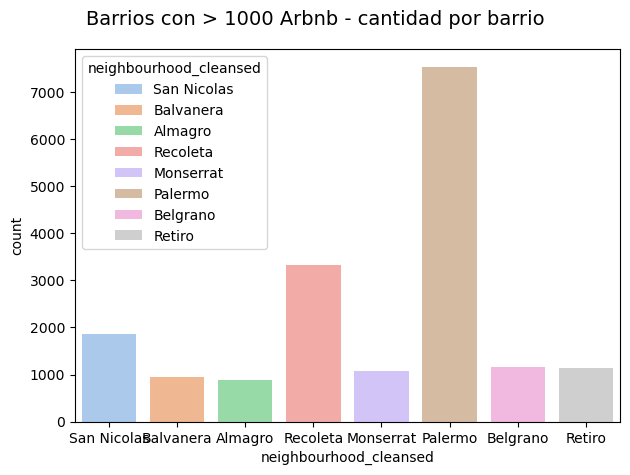

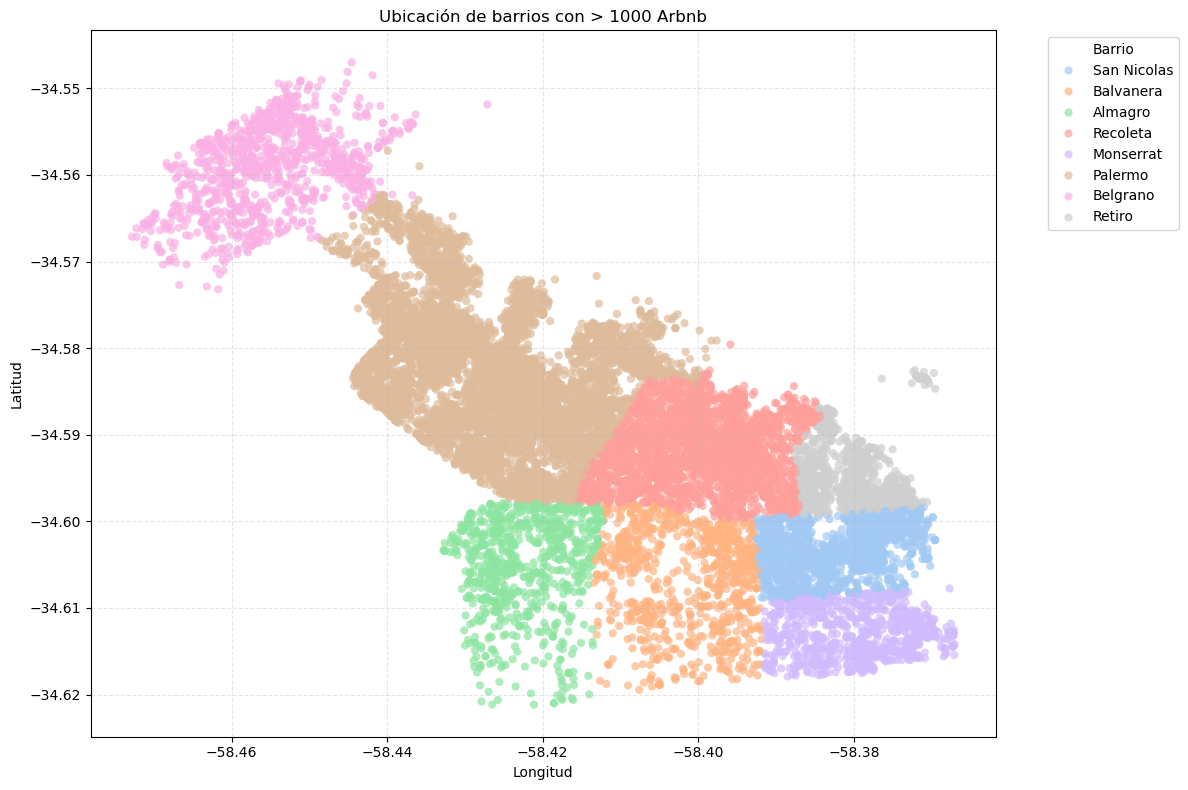

In [63]:
sns.countplot(x="neighbourhood_cleansed", data=top_barrios_df, hue="neighbourhood_cleansed", palette='pastel', legend='brief')

plt.suptitle('Barrios con > 1000 Arbnb - cantidad por barrio', fontsize=14)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 8))
sns.scatterplot(data=top_barrios_df, x='longitude', y='latitude', hue='neighbourhood_cleansed', palette='pastel', alpha=0.7, s=35, edgecolor='none')
plt.title('Ubicación de barrios con > 1000 Arbnb')
plt.xlabel('Longitud')
plt.ylabel('Latitud')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Barrio')
plt.grid(alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

Analizamos los barrios con mayor cantidad de reviews

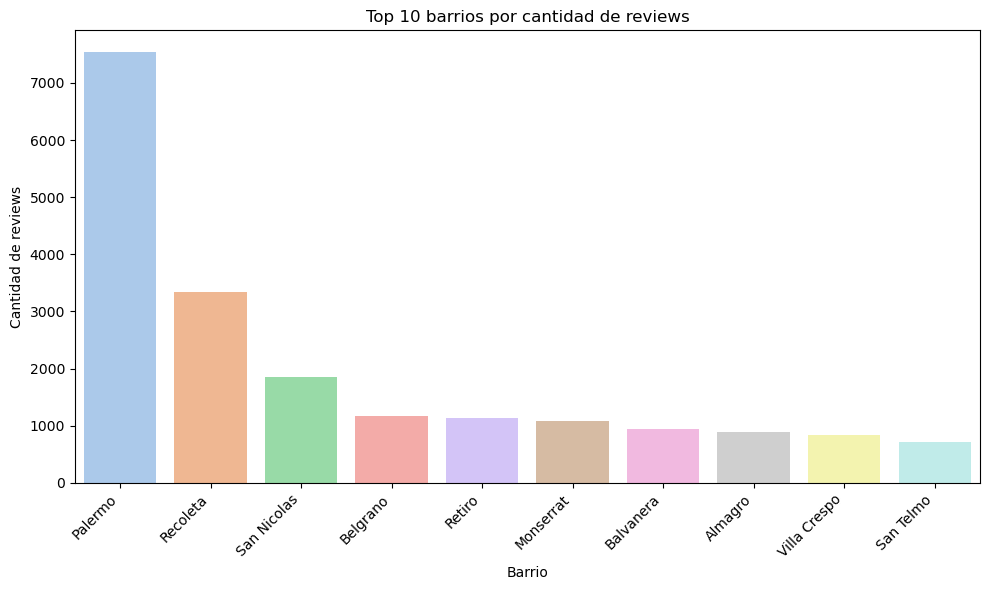

In [64]:
barrios_max = df4_1.groupby('neighbourhood_cleansed')["number_of_reviews"].count().sort_values(ascending=False).head(10)
top = barrios_max.reset_index(name='count')

plt.figure(figsize=(10,6))
sns.barplot(data=top, x='neighbourhood_cleansed', y='count', palette='pastel', 
            hue='neighbourhood_cleansed', legend=False, order=top['neighbourhood_cleansed'])
plt.title('Top 10 barrios por cantidad de reviews')
plt.xlabel('Barrio')
plt.ylabel('Cantidad de reviews')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Verificamos que barrios tienen mas disponibilidad

<Axes: xlabel='availability_365', ylabel='neighbourhood_cleansed'>

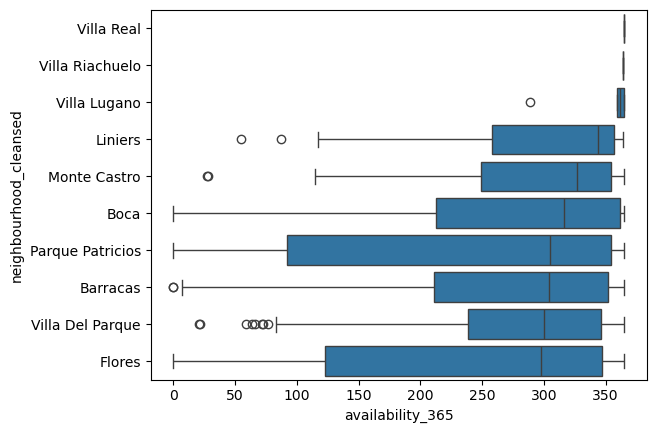

In [65]:
orden = df4_1.groupby('neighbourhood_cleansed')['availability_365'].median().sort_values(ascending=False).head(10).index
sns.boxplot(data=df4_1[df4_1['neighbourhood_cleansed'].isin(orden)], x='availability_365', y='neighbourhood_cleansed', order=orden)

Nos quedamos con los top 5 barrios y creamos atributos categoricos binarios para cada uno

In [66]:
df4_1["Palermo"] = df4_1["neighbourhood_cleansed"].str.contains("Palermo", case=False, na=False).astype(int)
df4_1["Recoleta"] = df4_1["neighbourhood_cleansed"].str.contains("Recoleta", case=False, na=False).astype(int)
df4_1["San Nicolas"] = df4_1["neighbourhood_cleansed"].str.contains("San Nicolas", case=False, na=False).astype(int)
df4_1["Belgrano"] = df4_1["neighbourhood_cleansed"].str.contains("Belgrano", case=False, na=False).astype(int)
df4_1["Retiro"] = df4_1["neighbourhood_cleansed"].str.contains("Retiro", case=False, na=False).astype(int)
df4_2 = df4_1.drop(columns=['neighbourhood_cleansed']).copy()
df4_2.head()


,id,hosts_time_as_user_months,hosts_time_as_host_months,host_is_superhost,host_listings_count,host_identity_verified,latitude,longitude,property_type,accommodates,bathrooms,bedrooms,beds,minimum_nights,maximum_nights,has_availability,availability_30,availability_60,availability_90,availability_365,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,availability_eoy,number_of_reviews_ly,estimated_occupancy_l365d,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,coffee,wifi,parking,air_conditioning,pool,gym,Palermo,Recoleta,San Nicolas,Belgrano,Retiro
0,42610838,86,71,1,3,t,-34.599976,-58.374195,Entire rental unit,2,1.0,1.0,1.0,7.0,365.0,t,30,35,36,244,0,0,0,220,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,1,0,1,0,0,0,0,1,0,0
1,1305876403852901802,132,43,0,1,t,-34.600382,-58.372692,Entire rental unit,2,1.0,1.0,1.0,2.0,365.0,t,7,16,32,307,1,0,0,283,1,0,3.00,4.00,2.00,3.00,3.00,5.00,4.00,0,1,1,1,0,0,0,0,1,0,0
2,1542233033640525302,99,94,0,1,t,-34.603295,-58.409527,Entire rental unit,2,1.0,1.0,2.0,7.0,365.0,t,0,21,51,326,0,0,0,302,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,1,0,1,0,0,0,0,0,0,0
3,1004530078359434134,170,169,0,48,t,-34.599230,-58.407060,Entire rental unit,2,1.0,1.0,1.0,1.0,365.0,t,30,60,90,365,22,3,0,341,3,18,4.73,4.64,4.64,4.82,4.73,4.59,4.45,0,1,0,1,0,0,0,0,0,0,0
4,800145927121871422,42,32,0,2,t,-34.599767,-58.426499,Entire rental unit,4,1.0,2.0,3.0,1.0,365.0,NaN,30,60,90,365,0,0,0,341,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,1,1,1,1,0,0,0,0,0,0


Grafico de disponibilidad

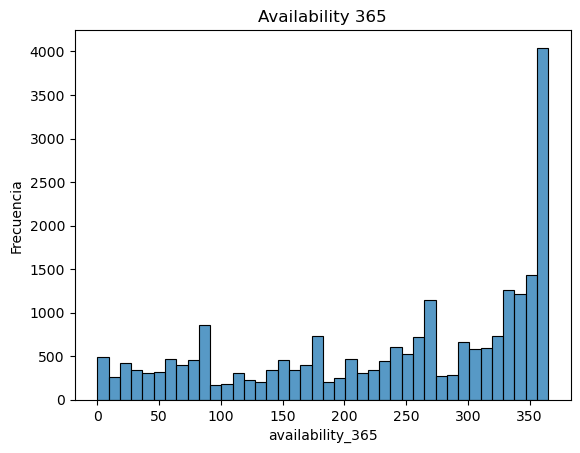

In [67]:
sns.histplot(df4_2["availability_365"].dropna(), bins=40)
plt.title("Availability 365")
plt.xlabel("availability_365")
plt.ylabel("Frecuencia")
plt.show()

Cantidad de reviews vs disponibilidad

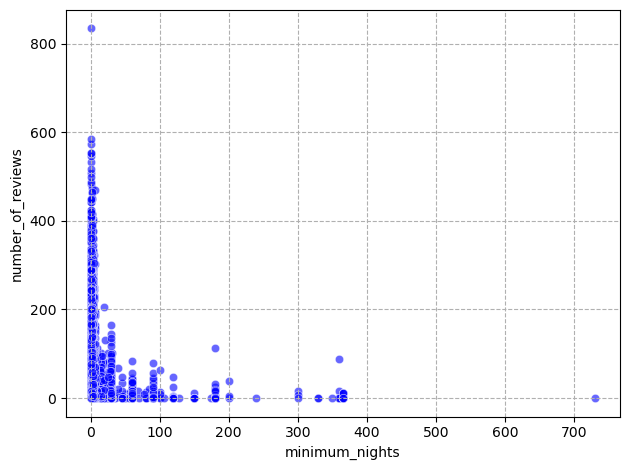

In [68]:
sns.scatterplot(data=df4_2, x='minimum_nights', y='number_of_reviews', color='b',alpha=0.6)
	
plt.grid(ls='--')
plt.title('')
plt.tight_layout()
plt.show()

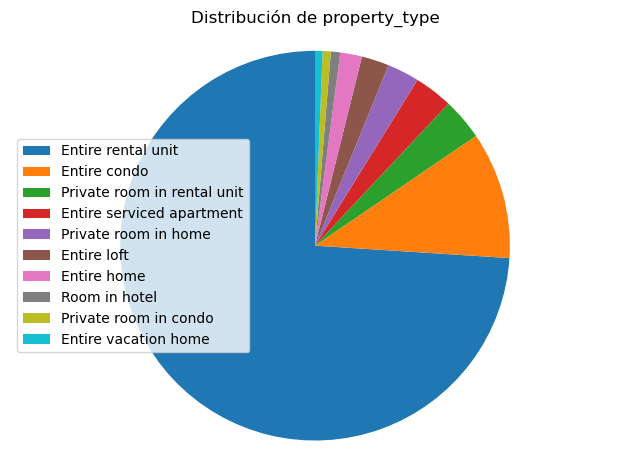

In [69]:
#plot_pie(Airbnb_df, "property_type")
top10 = df4_2["property_type"].value_counts().head(10).index
plot_prop_type = df4_2[df4_2["property_type"].isin(top10)]
colores = [
    "#1f77b4",  # blue
    "#ff7f0e",  # orange
    "#2ca02c",  # green
    "#d62728",  # red
    "#9467bd",  # purple
    "#8c564b",  # brown
    "#e377c2",  # pink
    "#7f7f7f",  # gray
    "#bcbd22",  # yellow‑green
    "#17becf"   # cyan
]

labels = plot_prop_type["property_type"].value_counts().index
patches, texts = plt.pie(plot_prop_type["property_type"].value_counts(), colors=colores, startangle=90)
plt.title(f'Distribución de property_type')
plt.legend(patches, labels, loc="best")
# Set aspect ratio to be equal so that pie is drawn as a circle.
plt.axis('equal')
plt.tight_layout()
plt.show()

Analizamos la distribucion de las variables asociadas con reviews

=== TABLA DE PERCENTILES ===

--- review_scores_rating ---
count    20778.000000
mean         4.780556
std          0.360032
min          1.000000
25%          4.730000
50%          4.870000
75%          4.980000
90%          5.000000
95%          5.000000
99%          5.000000
max          5.000000
Name: review_scores_rating, dtype: float64

--- review_scores_accuracy ---
count    20778.000000
mean         4.804204
std          0.348758
min          1.000000
25%          4.770000
50%          4.890000
75%          5.000000
90%          5.000000
95%          5.000000
99%          5.000000
max          5.000000
Name: review_scores_accuracy, dtype: float64

--- review_scores_cleanliness ---
count    20778.000000
mean         4.734777
std          0.383712
min          1.000000
25%          4.670000
50%          4.830000
75%          4.950000
90%          5.000000
95%          5.000000
99%          5.000000
max          5.000000
Name: review_scores_cleanliness, dtype: float64

--- review_

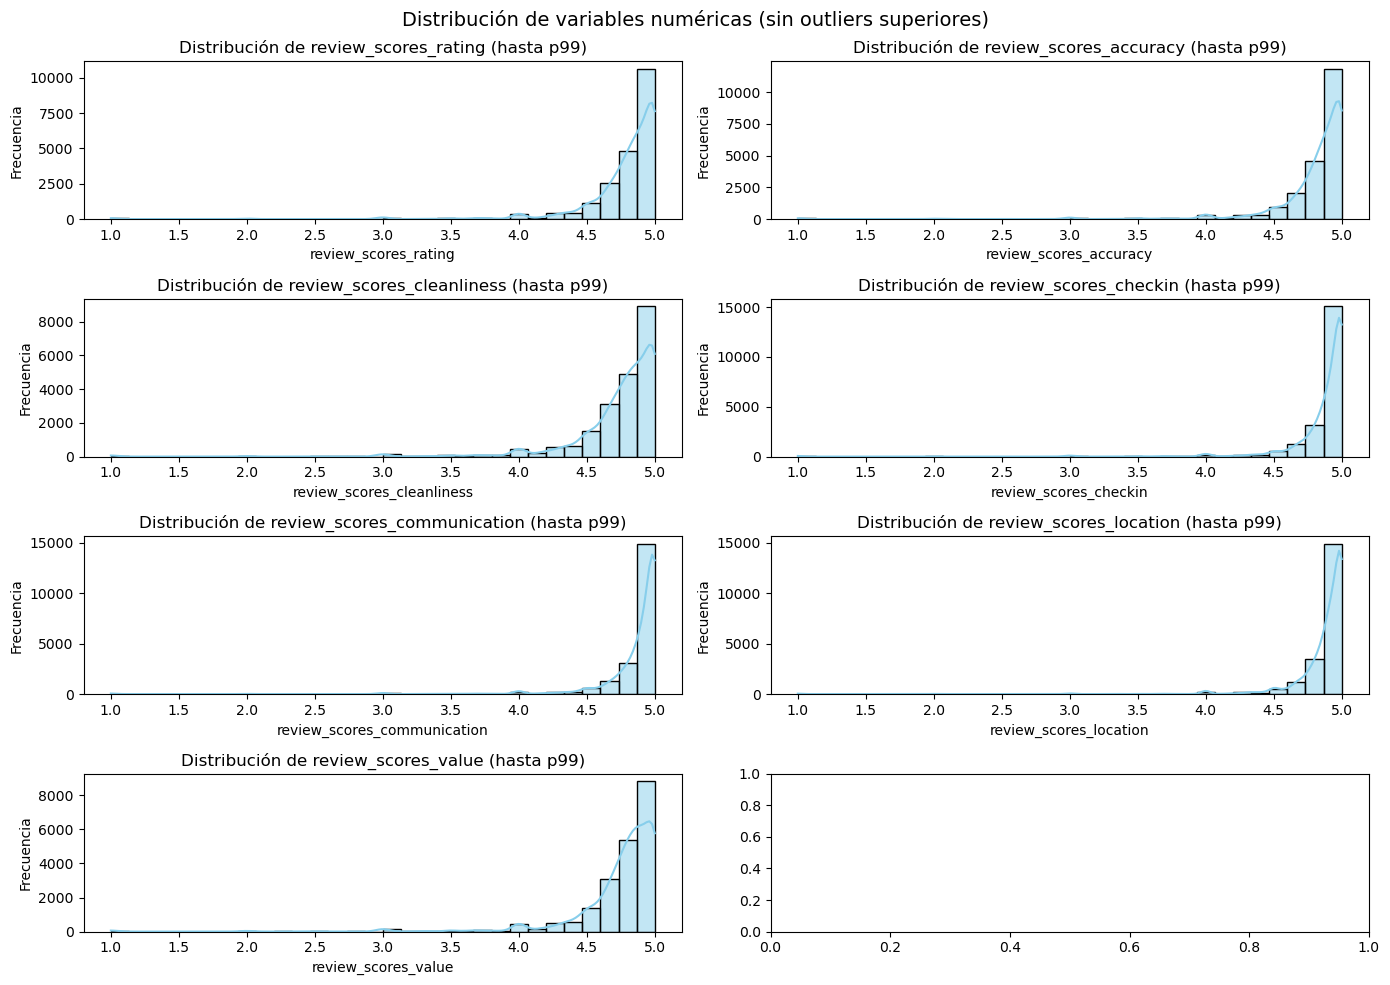

In [70]:
variables = ['review_scores_rating', 'review_scores_accuracy', 'review_scores_cleanliness', 'review_scores_checkin', 'review_scores_communication', 'review_scores_location', 'review_scores_value']

# Tabla de percentiles
print("=== TABLA DE PERCENTILES ===\n")
for var in variables:
    print(f"--- {var} ---")
    print(df4_2[var].describe(percentiles=[.25, .50, .75, .90, .95, .99]))
    print()

# Histogramas recortados por p99
fig, axes = plt.subplots(4, 2, figsize=(14, 10))
axes = axes.flatten()

for i, var in enumerate(variables):
    p99 = df4_2[var].quantile(0.99)
    datos = df4_2[df4_2[var] <= p99][var].dropna()
    
    sns.histplot(datos, bins=30, kde=True, ax=axes[i], color='skyblue')
    axes[i].set_title(f'Distribución de {var} (hasta p99)')
    axes[i].set_xlabel(var)
    axes[i].set_ylabel('Frecuencia')

plt.suptitle('Distribución de variables numéricas (sin outliers superiores)', fontsize=14)
plt.tight_layout()
plt.show()

* Se ve que hay muy pocos datos por debajo de 4.5/5. Esto es un poco desalentador porque pareceria indicar que los huespedes no utilizan el rango completo del puntaje para reflejar su experiencia en detalle. Esto hace a estos atributos menos utiles


Disponibilidad dependiendo del tipo de alojamiento

<Axes: xlabel='property_type', ylabel='availability_365'>

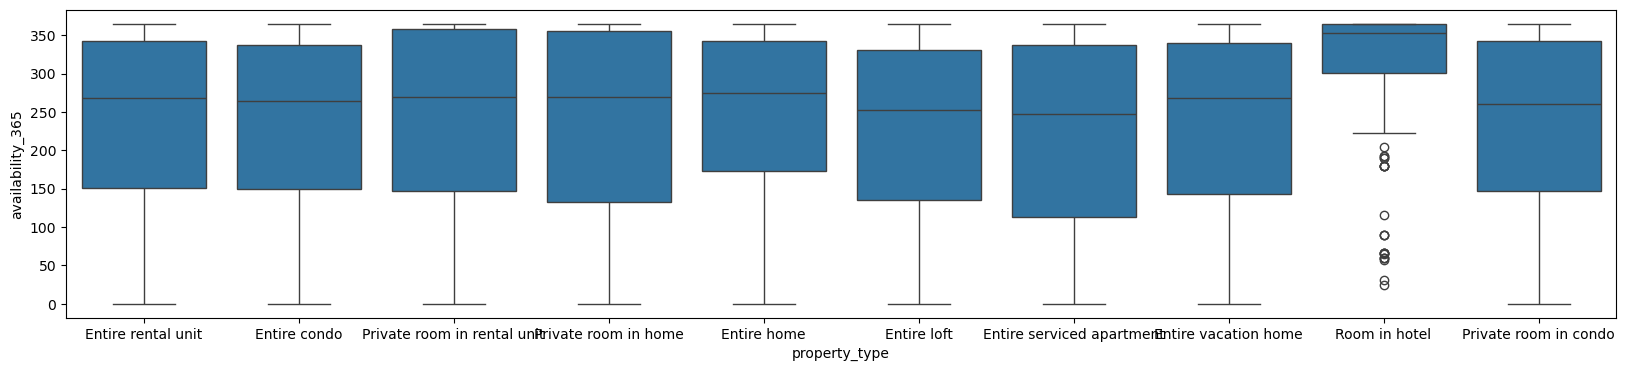

In [71]:
plt.figure(figsize=(20, 4))
sns.boxplot(data=plot_prop_type, x='property_type', y='availability_365')


Ralizamos una matriz de correlacion entre las variables numericas relacionadas con review y tiempo como host y usuario

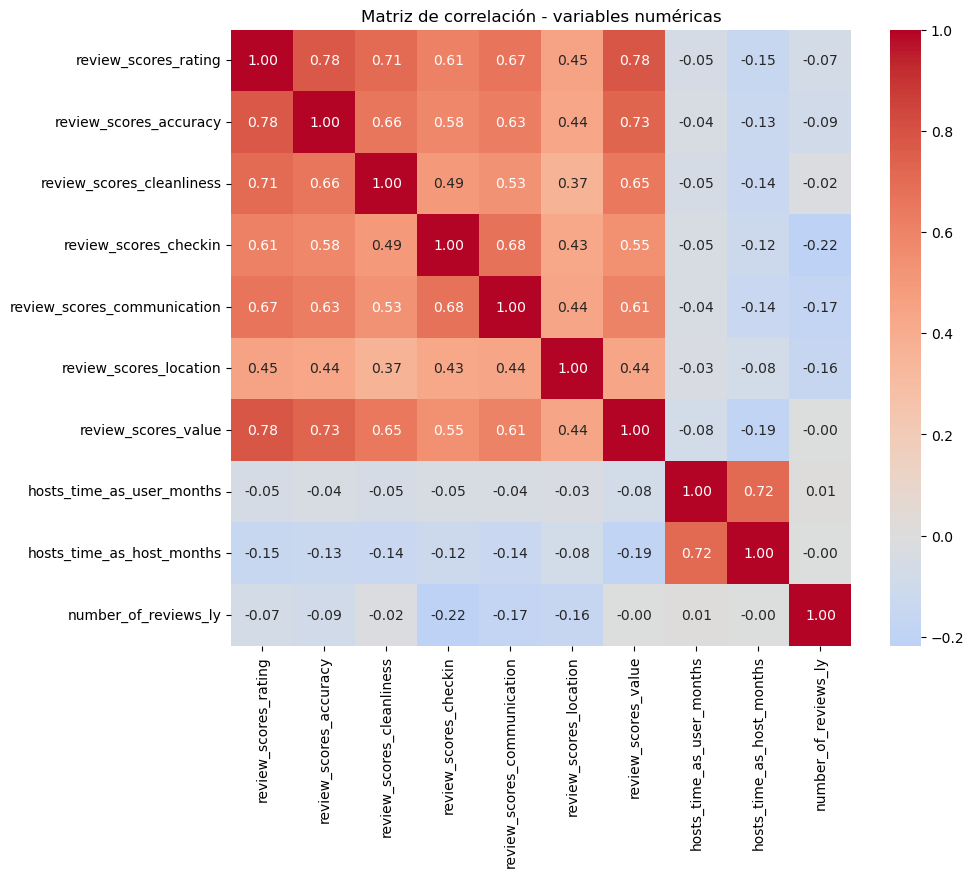

In [72]:
variables = ['review_scores_rating', 'review_scores_accuracy', 'review_scores_cleanliness', 'review_scores_checkin', 'review_scores_communication', 'review_scores_location', 'review_scores_value', 'hosts_time_as_user_months', 'hosts_time_as_host_months', 'number_of_reviews_ly']
corr = df4_2[variables].corr(method='spearman')

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Matriz de correlación - variables numéricas")
plt.show()

Interesante que la experiencia del host como host y como usuario no esta para nada correlacionada con los puntajes de los reviews. Esto es una buena noticia porque como inversores solo podemos elegir en que invertir, pero no podemos comprar tiempo de experiencia
Resulta interesante tambien hecho de que la correlacion mas fuerte de ratings (el puntaje mas importante) es con 'accuracy' y 'value'. Esto se puede interpretar como que los usuarion valoran mucho la exactitud de la descripcion del listing y la relacion calidad-precio (value for money)
Vemos que la cantidad de reviews anuales no esta correlacionada con el puntaje. Podemos estudiar si la cantidad de propiedades de un host esta relacionada con el puntaje, o sea si el host 'aprende' con la experiencia. Para esto repetimos el ejercicio con los atributos relevantes

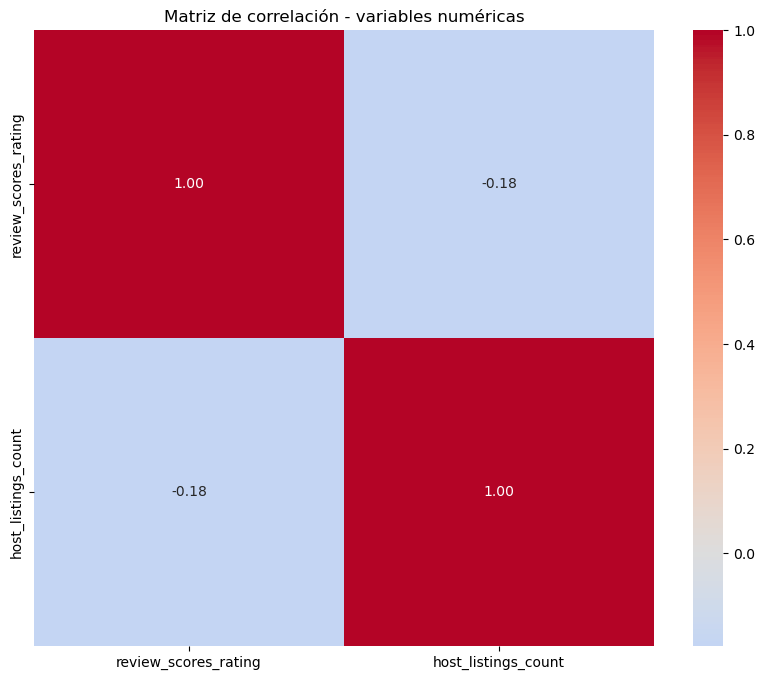

In [73]:
variables = ['review_scores_rating', 'host_listings_count']
corr = df4_2[variables].corr(method='spearman')

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Matriz de correlación - variables numéricas")
plt.show()

* Vemos que no hay correlacion relevante
* Y que ocurre con la relacion entre los amenities y el puntaje? Estamos buscando correlacion entre un feature categorico binario y uno numerico -> punto biserial

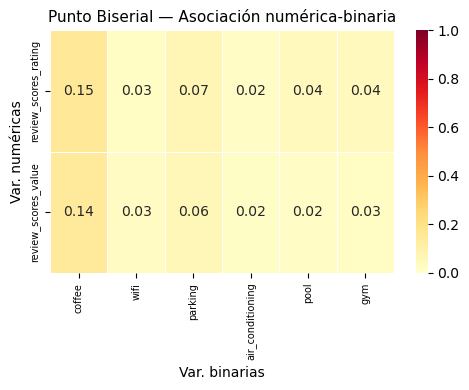

In [74]:
num_cols    = ['review_scores_rating', 'review_scores_value']
binarias = ['coffee',	'wifi',	'parking',	'air_conditioning', 'pool', 'gym']

pb_mat = pd.DataFrame(index=num_cols, columns=binarias, dtype=float)

for num_col in num_cols:
    for bin_col in binarias:
        mask = df4_2[num_col].notna() & df4_2[bin_col].notna()
        num  = df4_2.loc[mask, num_col]
        bn   = df4_2.loc[mask, bin_col]
        r, p = pointbiserialr(bn, num) # pointbiserialr Devuelve r y p-value, pero solo nos interesa r
        pb_mat.loc[num_col, bin_col] = abs(r)

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(pb_mat.astype(float), annot=True, fmt=".2f", cmap="YlOrRd",
            vmin=0, vmax=1, linewidths=0.5, ax=ax)

ax.set_title("Punto Biserial — Asociación numérica-binaria", fontsize=11)
ax.set_xlabel("Var. binarias")
ax.set_ylabel("Var. numéricas")
ax.set_xticklabels(ax.get_xticklabels(), fontsize=7)
ax.set_yticklabels(ax.get_yticklabels(), fontsize=7)
plt.tight_layout()
plt.show()

* Solo hay una correlacion debil entre los puntajes y el atributo cafe, con lo cual seria bueno equipar los AirBnB con caferetas

**Correlacion/Asociacion de atributos con target**

Ahora que tenemos una idea de que cosas prestar atencion como host, nos enfocamos en lo necesario para obtener la clasificacionb de superhost

Buscamos una asociacion entre amenities, barrio y estatus de superhost, que es algo muy interesante para nosotros porque esta muy relacionado al exito como empresarios de Airbnb.
Como son todas categoricas binarias utilizamos el coeficiente Phi

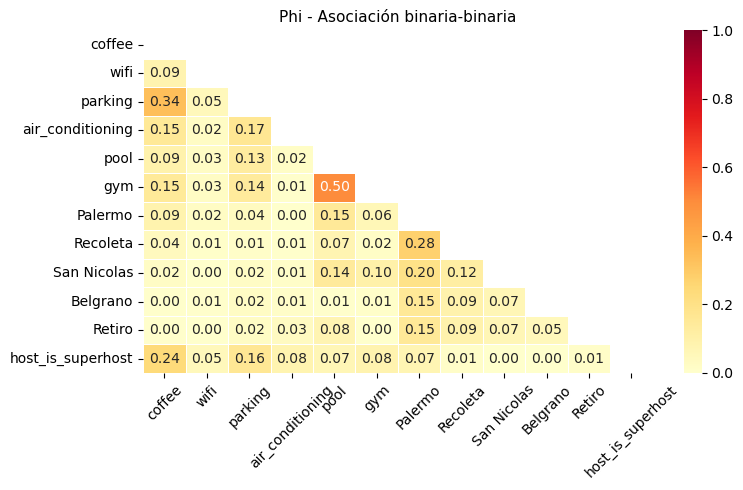

In [75]:

# Función para calcular Phi
def phi(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    return np.sqrt(chi2 / n) 

binarias = ['coffee', 'wifi', 'parking', 'air_conditioning', 'pool', 'gym', 'Palermo', 'Recoleta', 'San Nicolas', 'Belgrano', 'Retiro', 'host_is_superhost']
phi_mat = pd.DataFrame(index=binarias, columns=binarias, dtype=float)

for c1 in binarias:
    for c2 in binarias:
        if c1 == c2:
            phi_mat.loc[c1, c2] = 1.0
        else:
            mask = df4_2[c1].notna() & df4_2[c2].notna()
            x = df4_2.loc[mask, c1]
            y = df4_2.loc[mask, c2]
            phi_mat.loc[c1, c2] = phi(x, y)

# Máscara para mostrar solo la mitad inferior de la matriz
mask_upper = np.triu(np.ones_like(phi_mat, dtype=bool))

# Graficamos el heatmap
fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(phi_mat.astype(float), annot=True, fmt=".2f", cmap="YlOrRd",
            vmin=0, vmax=1, linewidths=0.5,
            mask=mask_upper, ax=ax)

ax.set_title("Phi - Asociación binaria-binaria", fontsize=11)
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

Vemos asociacion muy debil entre cafe y parking con superhost ya nada con los barrios top

Otra cuestion interesante es en que tipo de propiedades deberiamos invertir. Para eso buscamos asociacion entre tipo de propiedad (anteriormente encontramos el top 10, ahora nos quedamos con las 8 que son relevantes para nuestra inversion) y el target

In [76]:
df4_3 = df4_2
df4_3["entire_rental_unit"] = df4_2["property_type"].str.contains("Entire rental unit", case=False, na=False).astype(int)
df4_3["entire_condo"] = df4_3["property_type"].str.contains("Entire condo", case=False, na=False).astype(int)
df4_3["private_room"] = df4_3["property_type"].str.contains("Private room in rental unit", case=False, na=False).astype(int)
df4_3["entire_serviced_apartment"] = df4_3["property_type"].str.contains("Entire serviced apartment", case=False, na=False).astype(int)
df4_3["entire_loft"] = df4_3["property_type"].str.contains("Entire loft", case=False, na=False).astype(int)
df4_3 = df4_3.drop(columns=['property_type'])
df4_3.head()

,id,hosts_time_as_user_months,hosts_time_as_host_months,host_is_superhost,host_listings_count,host_identity_verified,latitude,longitude,accommodates,bathrooms,bedrooms,beds,minimum_nights,maximum_nights,has_availability,availability_30,availability_60,availability_90,availability_365,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,availability_eoy,number_of_reviews_ly,estimated_occupancy_l365d,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,coffee,wifi,parking,air_conditioning,pool,gym,Palermo,Recoleta,San Nicolas,Belgrano,Retiro,entire_rental_unit,entire_condo,private_room,entire_serviced_apartment,entire_loft
0,42610838,86,71,1,3,t,-34.599976,-58.374195,2,1.0,1.0,1.0,7.0,365.0,t,30,35,36,244,0,0,0,220,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,1,0,1,0,0,0,0,1,0,0,1,0,0,0,0
1,1305876403852901802,132,43,0,1,t,-34.600382,-58.372692,2,1.0,1.0,1.0,2.0,365.0,t,7,16,32,307,1,0,0,283,1,0,3.00,4.00,2.00,3.00,3.00,5.00,4.00,0,1,1,1,0,0,0,0,1,0,0,1,0,0,0,0
2,1542233033640525302,99,94,0,1,t,-34.603295,-58.409527,2,1.0,1.0,2.0,7.0,365.0,t,0,21,51,326,0,0,0,302,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,1,0,1,0,0,0,0,0,0,0,1,0,0,0,0
3,1004530078359434134,170,169,0,48,t,-34.599230,-58.407060,2,1.0,1.0,1.0,1.0,365.0,t,30,60,90,365,22,3,0,341,3,18,4.73,4.64,4.64,4.82,4.73,4.59,4.45,0,1,0,1,0,0,0,0,0,0,0,1,0,0,0,0
4,800145927121871422,42,32,0,2,t,-34.599767,-58.426499,4,1.0,2.0,3.0,1.0,365.0,NaN,30,60,90,365,0,0,0,341,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,1,1,1,1,0,0,0,0,0,0,1,0,0,0,0


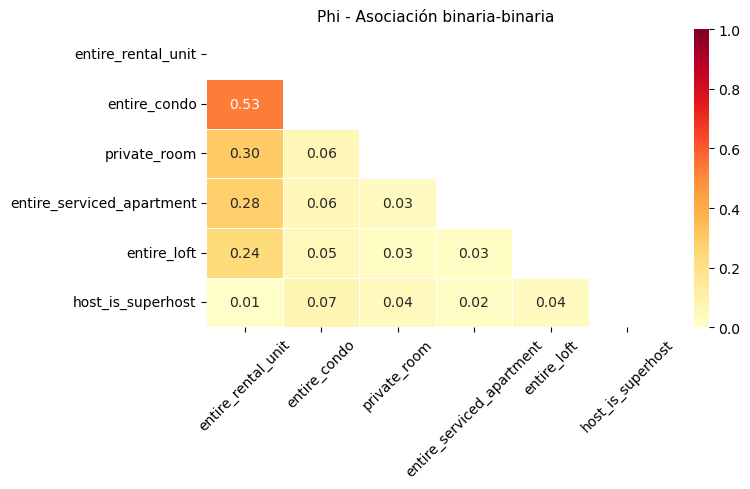

In [77]:
binarias = ['entire_rental_unit', 'entire_condo', 'private_room', 'entire_serviced_apartment', 'entire_loft', 'host_is_superhost']
phi_mat = pd.DataFrame(index=binarias, columns=binarias, dtype=float)

for c1 in binarias:
    for c2 in binarias:
        if c1 == c2:
            phi_mat.loc[c1, c2] = 1.0
        else:
            mask = df4_3[c1].notna() & df4_3[c2].notna()
            x = df4_3.loc[mask, c1]
            y = df4_3.loc[mask, c2]
            phi_mat.loc[c1, c2] = phi(x, y)

# Máscara para mostrar solo la mitad inferior de la matriz
mask_upper = np.triu(np.ones_like(phi_mat, dtype=bool))

# Graficamos el heatmap
fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(phi_mat.astype(float), annot=True, fmt=".2f", cmap="YlOrRd",
            vmin=0, vmax=1, linewidths=0.5,
            mask=mask_upper, ax=ax)

ax.set_title("Phi - Asociación binaria-binaria", fontsize=11)
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

Nuevamente, hay muy baja asociacion entre el tipo de propiedad y el target

Ahora estudiamos correlacion entre atributos numericos y el target

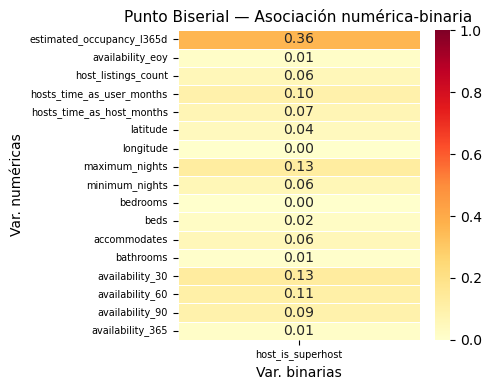

In [88]:
num_cols    = ['estimated_occupancy_l365d', 'availability_eoy', 'host_listings_count', 'hosts_time_as_user_months', 'hosts_time_as_host_months', 'latitude', 'longitude', 'maximum_nights', 'minimum_nights', 'bedrooms', 'beds', 'accommodates', 'bathrooms', 'availability_30', 'availability_60', 'availability_90', 'availability_365']
binarias = ['host_is_superhost']
	
pb_mat = pd.DataFrame(index=num_cols, columns=binarias, dtype=float)

for num_col in num_cols:
    for bin_col in binarias:
        mask = df4_3[num_col].notna() & df4_3[bin_col].notna()
        num  = df4_3.loc[mask, num_col]
        bn   = df4_3.loc[mask, bin_col]
        r, p = pointbiserialr(bn, num) # pointbiserialr Devuelve r y p-value, pero solo nos interesa r
        pb_mat.loc[num_col, bin_col] = abs(r)

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(pb_mat.astype(float), annot=True, fmt=".2f", cmap="YlOrRd",
            vmin=0, vmax=1, linewidths=0.5, ax=ax)

ax.set_title("Punto Biserial — Asociación numérica-binaria", fontsize=11)
ax.set_xlabel("Var. binarias")
ax.set_ylabel("Var. numéricas")
ax.set_xticklabels(ax.get_xticklabels(), fontsize=7)
ax.set_yticklabels(ax.get_yticklabels(), fontsize=7)
plt.tight_layout()
plt.show()

Observamos una debil correlacion con cantidad de noches maxima y disponibilidad en 30 dias
La correlacion con puntaje de reviews la tratamos por separado

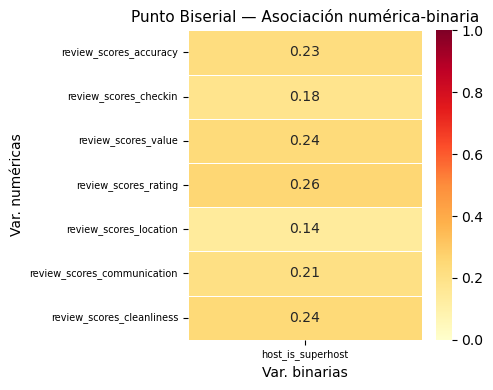

In [79]:
num_cols    = ['review_scores_accuracy', 'review_scores_checkin', 'review_scores_value', 'review_scores_rating', 'review_scores_location', 'review_scores_communication', 'review_scores_cleanliness']
	

binarias = ['host_is_superhost']

pb_mat = pd.DataFrame(index=num_cols, columns=binarias, dtype=float)

for num_col in num_cols:
    for bin_col in binarias:
        mask = df4_3[num_col].notna() & df4_3[bin_col].notna()
        num  = df4_3.loc[mask, num_col]
        bn   = df4_3.loc[mask, bin_col]
        r, p = pointbiserialr(bn, num) # pointbiserialr Devuelve r y p-value, pero solo nos interesa r
        pb_mat.loc[num_col, bin_col] = abs(r)

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(pb_mat.astype(float), annot=True, fmt=".2f", cmap="YlOrRd",
            vmin=0, vmax=1, linewidths=0.5, ax=ax)

ax.set_title("Punto Biserial — Asociación numérica-binaria", fontsize=11)
ax.set_xlabel("Var. binarias")
ax.set_ylabel("Var. numéricas")
ax.set_xticklabels(ax.get_xticklabels(), fontsize=7)
ax.set_yticklabels(ax.get_yticklabels(), fontsize=7)
plt.tight_layout()
plt.show()

Vemos que los reviews de ubicacion y checkin son peores predictores de la variable es superhost. Se puede utilizar la variable review_scores_rating como representative de la influencia de los reviews en el estatus de superhost

| Atributo | Asociacion con target | Usada en modelo |
|---|---|---|
| `id` | Irrelevante | NO |
| `hosts_time_as_user_months` | Debil | SI |
| `hosts_time_as_host_months` | Nula | NO |
| `host_is_superhost` | Target | SI |
| `host_listings_count` | Nula | NO |
| `host_identity_verified` | Irrelevante | NO |
| `longitude` | Nula | NO |
| `latitude` | Nula | NO |
| `accommodates` | Nula | NO |
| `bathrooms` | Nula | NO |
| `bedrooms` | Nula | NO |
| `beds` | Nula | NO |
| `minimum_nights` | Nula | NO |
| `has_availability` | Irrelevante | NO |
| `availability_30` | Debil | SI |
| `availability_60` | Debil | Si |
| `availability_90` | Nula | NO |
| `availability_365` | Nula | NO |
| `number_of_reviews` | Irrelevante | NO |
| `number_of_reviews_ltm` | Irrelevante | NO |
| `number_of_reviews_l30d` | Irrelevante | NO |
| `availability_eoy` | Nula | NO |
| `number_of_reviews_ly` | Irrelevante | NO |
| `estimated_occupancy_l365d` | Media | NO |
| `review_scores_rating` | Media | SI |
| `review_scores_accuracy` | Debil | SI |
| `review_scores_cleanliness` | Debil | SI |
| `review_scores_checkin` | Debil | SI |
| `review_scores_communication` | Debil | SI |
| `review_scores_location` | Debil | SI |
| `review_scores_value` | Debil | SI |
| `coffee` | Debil | SI |
| `wifi` | Nula | NO |
| `parking` | Debil | SI |
| `air_conditioning` | Nula | NO |
| `pool` | Nula | NO |
| `gym` | Nula | NO |
| `Palermo` | Nula | NO |
| `Recoleta` | Nula | NO |
| `San Nicolas` | Nula | NO |
| `Belgrano` | Nula | NO |
| `Retiro` | Nula | NO |
| `entire_rental_unit` | Nula | NO |
| `entire_condo` | Nula | NO |
| `private_room` | Nula | NO |
| `entire_serviced_apartment` | Nula | NO |
| `entire_loft` | Nula | NO |

In [94]:
cols = [
    "hosts_time_as_user_months",
    "host_is_superhost",
    "availability_30",
    "availability_60",
    "review_scores_rating",
    "review_scores_accuracy",
    "review_scores_cleanliness",
    "review_scores_checkin",
    "review_scores_communication",
    "review_scores_location",
    "review_scores_value",
    "coffee",
    "parking"
]
df_EDA = df4_3[cols]
df_EDA.head()

,hosts_time_as_user_months,host_is_superhost,availability_30,availability_60,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,coffee,parking
0,86,1,30,35,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0
1,132,0,7,16,3.00,4.00,2.00,3.00,3.00,5.00,4.00,0,1
2,99,0,0,21,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0
3,170,0,30,60,4.73,4.64,4.64,4.82,4.73,4.59,4.45,0,0
4,42,0,30,60,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,1


Ya tenemos el dataset con los atributos relevantes y el target listo para su procesamiento y limpieza

Primero estudiamos la distribucion del target

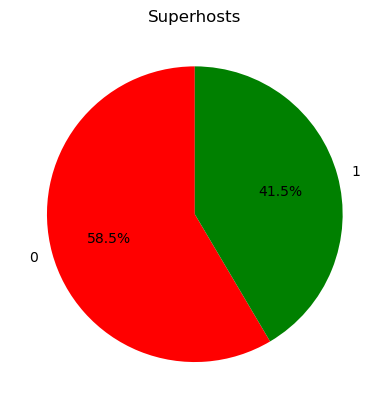

In [95]:
counts = df_EDA["host_is_superhost"].value_counts()

color_map = {
    1: "green",
    0: "red"
}

colors = [color_map[v] for v in counts.index]

counts.plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90,
    colors=colors
)

plt.title("Superhosts")
plt.ylabel("")
plt.show()

Venos que es un problema de clasificacion balanceado

**Analisis de faltantes**

Ahora estudiamos el porcentaje de nulos de las variables que quedan

In [96]:
pd.set_option('display.max_rows', None)
print((df_EDA.isnull().sum() / len(df_EDA) * 100).sort_values(ascending=False).round(2))

review_scores_rating           12.38
review_scores_accuracy         12.38
review_scores_cleanliness      12.38
review_scores_checkin          12.38
review_scores_communication    12.38
review_scores_location         12.38
review_scores_value            12.38
hosts_time_as_user_months       0.00
host_is_superhost               0.00
availability_30                 0.00
availability_60                 0.00
coffee                          0.00
parking                         0.00
dtype: float64
